# Approaches 1 and 2: TF-IDF Baselines

*Formative Assignment 2: NLP and Language Technologies*

**Authors:** Mahlet Assefa Tilahun (Approach 1), Tedla Tesfaye Godebo (Approach 2)

Both baselines represent an article as a bag of TF-IDF-weighted words, so they **ignore word order completely**. They show how far topic keywords alone can go, and they are the reference the three neural sequence models in `03_neural_models.ipynb` have to beat.

- **Approach 1:** TF-IDF + Logistic Regression (discriminative).
- **Approach 2:** TF-IDF + Naive Bayes (generative; multinomial and Complement variants).

Settings are chosen by 5-fold stratified cross-validation on the training part only; the validation part is used once, for reporting. Every experiment is logged in `results/experiments.csv`.

## Setup
Run this cell first. On Google Colab it clones the repository and asks you to upload `Train.csv` (and `Test.csv`) from the Zindi data page; locally it only adds the repository root to the Python path.

In [1]:
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("src").exists():
    if not Path("/content/formativeII-NLP").exists():
        !git clone -q https://github.com/mukunzindahiro-max/formativeII-NLP.git /content/formativeII-NLP
    %cd /content/formativeII-NLP

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data import DATA_DIR

if "google.colab" in sys.modules and not (DATA_DIR / "Train.csv").exists():
    from google.colab import files
    for name, content in files.upload().items():
        (DATA_DIR / name).write_bytes(content)

## 1. Data
`load_split()` applies the shared cleaning from `src/data.py` (re-joins the 255 list-formatted `michezo` rows and drops the 3 near-empty rows) and returns the fixed stratified split from `data/split_ids.csv`, so all five models see exactly the same articles.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline

from src.data import FIGURES_DIR, LABELS, RESULTS_DIR, SEED, load_split
from src.evaluate import align_proba, compute_metrics, evaluate, load_experiments, log_experiment, plot_confusion

train_df, val_df = load_split()
pd.DataFrame({"train": train_df["category"].value_counts(),
              "validation": val_df["category"].value_counts()}).loc[LABELS]

,train,validation
category,,
Kitaifa,1600,400
michezo,1375,344
Biashara,1087,272
Kimataifa,43,11
Burudani,13,3


In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

def run_grid(pipe, grid):
    start = time.time()
    search = GridSearchCV(pipe, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    search.fit(train_df["content"], train_df["category"])
    elapsed = time.time() - start
    model = search.best_estimator_
    proba = align_proba(model.predict_proba(val_df["content"]), model.classes_)
    metrics, _ = compute_metrics(val_df["category"].to_numpy(), proba)
    return {"search": search, "proba": proba, "metrics": metrics, "time": elapsed}

def cv_table(runs, params):
    tables = []
    for name, run in runs.items():
        t = pd.DataFrame(run["search"].cv_results_)[params + ["mean_test_score", "std_test_score"]]
        tables.append(t.assign(experiment=name))
    return pd.concat(tables).sort_values("mean_test_score", ascending=False).round(3).reset_index(drop=True)

## 2. Approach 1: TF-IDF + Logistic Regression

**Author:** Mahlet Assefa Tilahun

TF-IDF uses sublinear term frequency (`1 + log tf`, so a word repeated 20 times does not dominate) and ignores words seen in fewer than 2 training articles. Three experiments:

1. `lr_unigram`: single words, `class_weight="balanced"`, `C` in {0.1, 1, 10, 100}.
2. `lr_bigram`: single words and word pairs. Pairs such as *benki kuu* ("central bank") might separate `Biashara` from `Kitaifa`.
3. `lr_unigram_unweighted`: as experiment 1 but without class weights, to measure how much weighting helps the two small classes.

In [4]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ("clf", LogisticRegression(max_iter=2000)),
])
lr_experiments = {
    "lr_unigram": ({"tfidf__ngram_range": [(1, 1)], "clf__class_weight": ["balanced"]}, "unigrams, balanced class weights"),
    "lr_bigram": ({"tfidf__ngram_range": [(1, 2)], "clf__class_weight": ["balanced"]}, "unigrams + bigrams, balanced class weights"),
    "lr_unigram_unweighted": ({"tfidf__ngram_range": [(1, 1)], "clf__class_weight": [None]}, "unigrams, no class weights"),
}
lr_runs, logged = {}, []
for name, (grid, change) in lr_experiments.items():
    run = run_grid(lr_pipe, {**grid, "clf__C": [0.1, 1, 10, 100]})
    lr_runs[name] = run
    logged.append(log_experiment("tfidf_logreg", name, f"{change}, best C={run['search'].best_params_['clf__C']}",
                                 run["search"].best_score_, run["metrics"], run["time"]))
pd.concat(logged, ignore_index=True)

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,tfidf_logreg,lr_unigram,"unigrams, balanced class weights, best C=1",0.6503,0.6326,0.8789,0.8738,0.4575,22.0
1,tfidf_logreg,lr_bigram,"unigrams + bigrams, balanced class weights, be...",0.6145,0.6278,0.8596,0.8534,1.0048,58.1
2,tfidf_logreg,lr_unigram_unweighted,"unigrams, no class weights, best C=100",0.5515,0.5892,0.8794,0.8767,0.3801,20.8


In [5]:
cv_table(lr_runs, ["param_clf__C"])

,param_clf__C,mean_test_score,std_test_score,experiment
0,1.0,0.650,0.076,lr_unigram
1,0.1,0.628,0.057,lr_unigram
2,100.0,0.625,0.068,lr_unigram
3,10.0,0.625,0.070,lr_unigram
4,0.1,0.614,0.058,lr_bigram
5,1.0,0.577,0.060,lr_bigram
6,100.0,0.573,0.064,lr_bigram
7,10.0,0.572,0.065,lr_bigram
8,100.0,0.551,0.054,lr_unigram_unweighted
9,10.0,0.519,0.002,lr_unigram_unweighted


**Result:** the best setting is single words with balanced class weights and `C=1` (cross-validation macro-F1 0.650).
- **Word pairs hurt.** Adding bigrams made every setting worse (best 0.614). Bigrams add many features, but most pairs occur in only a few of the ~4k training articles, so they add noise faster than signal.
- **Class weights matter for the small classes.** Without weights, cross-validation macro-F1 drops by 0.10 (0.551 vs 0.650) while validation accuracy stays the same (0.877 vs 0.874). The whole difference is in the two small classes, exactly the pattern that accuracy hides and macro-F1 exposes.
- **Weights cost calibration.** The unweighted model has the *better* log loss (0.380 vs 0.457): weighting shifts probability towards the small classes, which is paid for on the many large-class articles. This is the trade-off anticipated in notebook 01, Section 8.
- The cross-validation standard deviation (0.06-0.08) is as large as the gaps between `C` values, because each fold holds only 2-3 `Burudani` articles.

### 2.1 Validation results of the selected model
The experiment with the best cross-validation macro-F1 is evaluated on the validation set and saved to `results/` for the final comparison.

Selected: lr_unigram {'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': (1, 1)}


tfidf_logreg: macro-F1 0.633 (95% CI 0.561-0.684), accuracy 0.874, log loss 0.457
              precision    recall  f1-score   support

     Kitaifa      0.851     0.843     0.847       400
     michezo      0.958     0.936     0.947       344
    Biashara      0.819     0.868     0.843       272
   Kimataifa      0.625     0.455     0.526        11
    Burudani      0.000     0.000     0.000         3

    accuracy                          0.874      1030
   macro avg      0.651     0.620     0.633      1030
weighted avg      0.874     0.874     0.873      1030



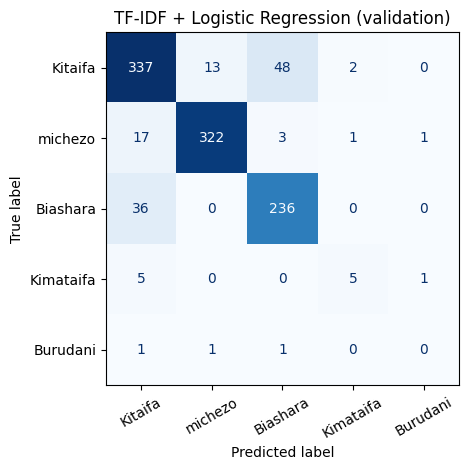

In [6]:
best_lr = max(lr_runs, key=lambda k: lr_runs[k]["search"].best_score_)
lr_model = lr_runs[best_lr]["search"].best_estimator_
print("Selected:", best_lr, lr_runs[best_lr]["search"].best_params_)
lr_metrics, lr_pred = evaluate("tfidf_logreg", val_df, lr_runs[best_lr]["proba"])
plot_confusion(val_df["category"], lr_pred, "TF-IDF + Logistic Regression (validation)", save_as="cm_tfidf_logreg.png")
plt.show()

**Result:** validation accuracy is 0.874 but macro-F1 only 0.633 (95% CI 0.561-0.684). The three large classes all reach F1 ≥ 0.84 (three-class macro-F1 0.879), but the model misses all 3 `Burudani` articles and 6 of the 11 `Kimataifa` ones. The width of the confidence interval (0.12) shows how strongly those 14 articles drive the macro-F1.

### 2.2 What did the model learn?
The 12 words with the largest weight for each category.

In [7]:
vocab = np.array(lr_model.named_steps["tfidf"].get_feature_names_out())
clf = lr_model.named_steps["clf"]
pd.DataFrame({cls: vocab[np.argsort(clf.coef_[i])[::-1][:12]] for i, cls in enumerate(clf.classes_)})[LABELS]

,Kitaifa,michezo,Biashara,Kimataifa,Burudani
0,magufuli,timu,biashara,rais,brown
1,wananchi,mchezo,uwekezaji,huawei,mwanamuziki
2,serikali,klabu,wafanyabiashara,kiongozi,google
3,wilaya,michezo,bidhaa,nairobi,runner
4,dk,soka,benki,china,miss
5,john,simba,alisema,virusi,music
6,sheria,wachezaji,bei,mugabe,chris
7,wanafunzi,yanga,wateja,kenya,davido
8,mradi,ligi,huduma,marekani,wimbo
9,watoto,mechi,viwanda,nyambizi,mitandao


**Result:** the weights are clear topic keywords (*timu, yanga, ligi* for sport; *benki, uwekezaji* "investment" for business; *kenya, china, trump* for international news). Many are **names**: *magufuli* (the president at the time) is the strongest `Kitaifa` word, and `Burudani` relies on artist names (*davido, chris, brown*) alongside genre words (*wimbo* "song", *mwanamuziki* "musician"). Names learned from 13 training articles will not transfer to new artists, and name-based features become outdated as the news changes.

### 2.3 Mistakes
Validation mistakes (with text) are saved to `results/errors_tfidf_logreg.csv`; the file is git-ignored because it contains dataset text.

In [8]:
lr_errors = val_df.assign(predicted=lr_pred, confidence=lr_runs[best_lr]["proba"].max(axis=1).round(3))
lr_errors = lr_errors[lr_errors["category"] != lr_errors["predicted"]]
lr_errors[["id", "category", "predicted", "confidence", "content"]].to_csv(RESULTS_DIR / "errors_tfidf_logreg.csv", index=False)
print(f"{len(lr_errors)} of {len(val_df)} validation articles misclassified")
pd.crosstab(lr_errors["category"], lr_errors["predicted"])

130 of 1030 validation articles misclassified


predicted,Biashara,Burudani,Kimataifa,Kitaifa,michezo
category,,,,,
Biashara,0,0,0,36,0
Burudani,1,0,0,1,1
Kimataifa,0,1,0,5,0
Kitaifa,48,0,2,0,13
michezo,3,1,1,17,0


In [9]:
pd.set_option("display.max_colwidth", 300)
lr_errors.sort_values("confidence", ascending=False)[["category", "predicted", "confidence", "content"]].head(5)

,category,predicted,confidence,content
128,Kitaifa,michezo,0.937,"LICHA ya kuwafunga waajiri wake wazamani Yanga, Mshambuliaji wa Azam FC , Obrey Chirwa (pichani) ameonesha kutoridhika na hali hiyo na kudai kuwa anaitaka Yanga yenyewe iliyotimia akimaanisha ile ya wakubwa.Chirwa alifunga bao la tatu katika mchezo wa Kombe la Mapinduzi juzi dhidi ya Yanga, mche..."
925,Kitaifa,michezo,0.889,"KOCHA wa Real Madrid, Zinedine Zidane, amesema kuwa anataka timu ya taifa ya Algeria kushinda taji la mashindano ya Mataifa ya Afrika, (Afcon 2019).Zidane ana asili ya Algeria lakini aliamua kuiwakilisha Ufaransa katika mashindano ya kimataifa, ambapo aliiongoza Ufaransa kushida Kombe la Dunia 1..."
527,Kitaifa,michezo,0.887,"ZIKIWA zimebaki saa chache kabla ya kuanza kwa fainali za 32 za Mataifa ya Afrika (Afcon 2019) Misri, Shirikisho la Soka Afrika (Caf) limesema kuwa kila kitu kiko tayari kwa ajili ya ufunguzi rasmi.Naibu Katibu Mkuu wa Caf anayeshughulikia Soka na Maendeleo, Anthony Baffoe alisema kuwa kila kitu..."
855,Kitaifa,Biashara,0.886,"KAMPUNI ya Sukari ya Kilombero (KSC) imesema mpango wa Taasisi ya Kuendeleza Kilimo Nyanda za Juu Kusini mwa Tanzania (SAGCOT), kuanza kutekelezwa wilayani Kilombero mkoani Morogoro, utawajengea uwezo zaidi wakulima wa miwa kulima kibiashara sambamba na kuongeza uzalishaji.Hayo yalisemwa na Mkur..."
816,Kitaifa,michezo,0.886,"WADAU wa soka nchini wamesema timu ya taifa ya soka ya Tanzania Taifa Stars inaweza kufanikiwa kuidhibiti Senegal katika mchezo wa kesho, iwapo tu watazingatia maelekezo wanayopewa na Kocha Mkuu Emmanuel Amunike.Stars itafungua dimba kesho katika mchezo wake wa kwanza wa Kundi C, dhidi ya Senega..."


**Result:** 84 of the 130 mistakes (65%) are between `Kitaifa` and `Biashara` (48 national articles predicted as business, 36 the other way). National economic news overlaps with business news, and notebook 01 found near-identical articles carrying both labels, so part of this error is label noise rather than model failure.

The most confident mistakes are football articles (Yanga, Afcon 2019, Taifa Stars) labelled `Kitaifa` and predicted `michezo` with probability 0.89-0.94. These are either labelling errors or a labelling convention (for example, national-team football filed as national news) that no model can infer from the text.

## 3. Approach 2: TF-IDF + Naive Bayes

**Author:** Tedla Tesfaye Godebo

Naive Bayes models how often each word occurs in each category and assumes words are independent given the category. It is applied to the same TF-IDF features (unigrams, the better n-gram setting from Section 2). The smoothing parameter `alpha` is tuned in {0.01, 0.03, 0.1, 0.3, 1}. Three variants target the class imbalance:

1. `nb_multinomial`: class prior learned from the data, which pushes predictions towards the large classes.
2. `nb_multinomial_uniform_prior`: all classes get the same prior, so only the words decide.
3. `nb_complement`: Complement NB (Rennie et al., 2003) estimates each class from all *other* classes, which gives small classes more stable estimates.

In [10]:
nb_experiments = {
    "nb_multinomial": (MultinomialNB(), "multinomial NB, learned class prior"),
    "nb_multinomial_uniform_prior": (MultinomialNB(fit_prior=False), "multinomial NB, uniform class prior"),
    "nb_complement": (ComplementNB(), "Complement NB"),
}
nb_runs, logged = {}, []
for name, (estimator, change) in nb_experiments.items():
    pipe = Pipeline([("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)), ("clf", estimator)])
    run = run_grid(pipe, {"clf__alpha": [0.01, 0.03, 0.1, 0.3, 1.0]})
    nb_runs[name] = run
    logged.append(log_experiment("tfidf_nb", name, f"{change}, best alpha={run['search'].best_params_['clf__alpha']}",
                                 run["search"].best_score_, run["metrics"], run["time"]))
pd.concat(logged, ignore_index=True)

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,tfidf_nb,nb_multinomial,"multinomial NB, learned class prior, best alpha=0.01",0.5410,0.5430,0.8494,0.8447,0.5654,13.3
1,tfidf_nb,nb_multinomial_uniform_prior,"multinomial NB, uniform class prior, best alpha=0.01",0.6419,0.6212,0.8576,0.8524,0.5264,13.4
2,tfidf_nb,nb_complement,"Complement NB, best alpha=0.1",0.5134,0.5201,0.8669,0.8621,0.4841,13.2


In [11]:
cv_table(nb_runs, ["param_clf__alpha"]).head(10)

,param_clf__alpha,mean_test_score,std_test_score,experiment
0,0.01,0.642,0.091,nb_multinomial_uniform_prior
1,0.03,0.565,0.065,nb_multinomial_uniform_prior
2,0.01,0.541,0.054,nb_multinomial
3,0.10,0.538,0.054,nb_multinomial_uniform_prior
4,0.10,0.513,0.008,nb_complement
5,0.30,0.513,0.007,nb_complement
6,0.03,0.510,0.007,nb_complement
7,0.03,0.509,0.005,nb_multinomial
8,0.10,0.509,0.005,nb_multinomial
9,0.30,0.508,0.007,nb_multinomial_uniform_prior


**Result:** for Naive Bayes, the class prior matters most.
- With the learned prior, cross-validation macro-F1 is only 0.541: the prior probability of `Burudani` is about 0.3%, and the words of an entertainment article rarely overcome it.
- A **uniform prior** raises it to 0.642, close to logistic regression (0.650).
- **Complement NB**, designed for skewed classes (Rennie et al., 2003), is the *worst* variant here (0.513). It estimates each class from all the other classes; for the two tiny classes these complements are almost the whole corpus and nearly identical, which likely makes the small classes hard to tell apart.
- The best multinomial variants use the smallest smoothing value tried (`alpha=0.01`), so values below 0.01 are worth testing in future work.

Selected: nb_multinomial_uniform_prior {'clf__alpha': 0.01}


tfidf_nb: macro-F1 0.621 (95% CI 0.538-0.680), accuracy 0.852, log loss 0.526
              precision    recall  f1-score   support

     Kitaifa      0.801     0.845     0.822       400
     michezo      0.963     0.898     0.929       344
    Biashara      0.808     0.835     0.821       272
   Kimataifa      1.000     0.364     0.533        11
    Burudani      0.000     0.000     0.000         3

    accuracy                          0.852      1030
   macro avg      0.714     0.588     0.621      1030
weighted avg      0.857     0.852     0.852      1030



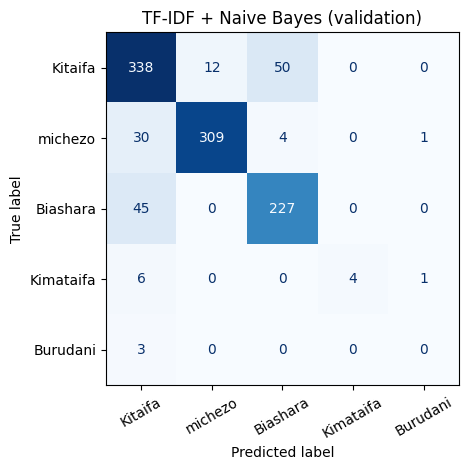

In [12]:
best_nb = max(nb_runs, key=lambda k: nb_runs[k]["search"].best_score_)
nb_model = nb_runs[best_nb]["search"].best_estimator_
print("Selected:", best_nb, nb_runs[best_nb]["search"].best_params_)
nb_metrics, nb_pred = evaluate("tfidf_nb", val_df, nb_runs[best_nb]["proba"])
plot_confusion(val_df["category"], nb_pred, "TF-IDF + Naive Bayes (validation)", save_as="cm_tfidf_nb.png")
plt.show()

In [13]:
nb_vocab = np.array(nb_model.named_steps["tfidf"].get_feature_names_out())
log_prob = nb_model.named_steps["clf"].feature_log_prob_
relative = log_prob - log_prob.mean(axis=0)
classes = nb_model.named_steps["clf"].classes_
pd.DataFrame({cls: nb_vocab[np.argsort(relative[i])[::-1][:12]] for i, cls in enumerate(classes)})[LABELS]

,Kitaifa,michezo,Biashara,Kimataifa,Burudani
0,mtuhumiwa,ligi,kilimo,mutharika,runner
1,vvu,mechi,zstc,nyambizi,2nd
2,majimbo,mchezaji,karafuu,arap,1st
3,masauni,liverpool,airtel,nato,google
4,dengue,kumsajili,dse,corona,music
5,kilimo,tottenham,tani,mugabe,aka
6,hakimu,wachezaji,mazao,maombolezo,kashinda
7,risasi,kocha,mazrui,huawei,kuuondoa
8,udahili,mail,viwanda,nyuklia,brown
9,lukuvi,mabingwa,nagu,cocaine,davido


**Result:** validation macro-F1 is 0.621 (95% CI 0.538-0.680) and accuracy 0.852. `Kimataifa` precision is perfect but recall only 0.36, and `Burudani` is never predicted correctly.

Naive Bayes' most indicative words are rarer and more specific than logistic regression's: politicians (*mutharika*, *lukuvi*, *masauni*), foreign clubs (*liverpool*, *tottenham*, *juventus*) and beauty-pageant terms for `Burudani` (*1st*, *2nd*, *runner*). With very little smoothing, a word that occurs only in one class gets an extreme score, so the model relies heavily on rare names.

## 4. Comparing the two baselines

In [14]:
comparison = pd.DataFrame({"TF-IDF + LR": lr_metrics, "TF-IDF + NB": nb_metrics}).T
comparison[["macro_f1", "macro_f1_ci_low", "macro_f1_ci_high", "macro_f1_major", "accuracy", "log_loss"]
           + [f"f1_{l}" for l in LABELS]].round(3)

,macro_f1,macro_f1_ci_low,macro_f1_ci_high,macro_f1_major,accuracy,log_loss,f1_Kitaifa,f1_michezo,f1_Biashara,f1_Kimataifa,f1_Burudani
TF-IDF + LR,0.633,0.561,0.684,0.879,0.874,0.457,0.847,0.947,0.843,0.526,0.0
TF-IDF + NB,0.621,0.538,0.680,0.858,0.852,0.526,0.822,0.929,0.821,0.533,0.0


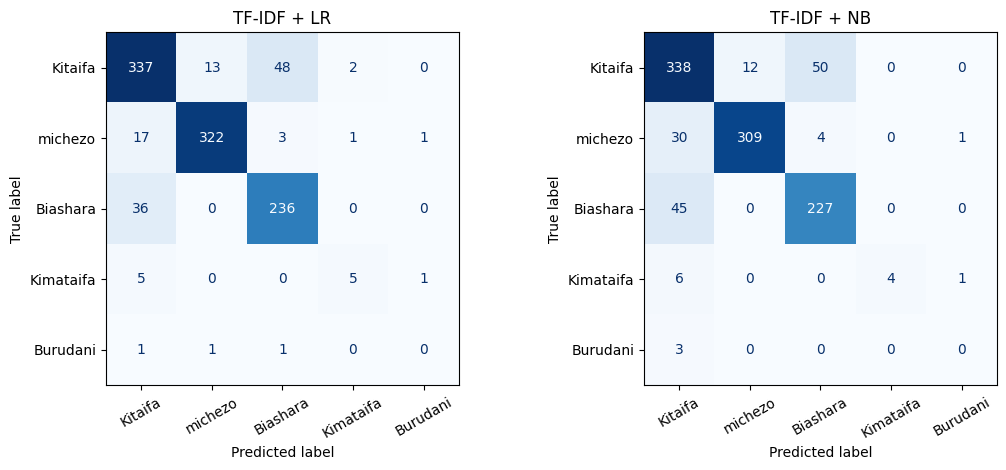

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
plot_confusion(val_df["category"], lr_pred, "TF-IDF + LR", ax=axes[0])
plot_confusion(val_df["category"], nb_pred, "TF-IDF + NB", ax=axes[1])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cm_baselines.png", dpi=150)
plt.show()

In [16]:
load_experiments().query("model in ['tfidf_logreg', 'tfidf_nb']")

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,tfidf_logreg,lr_unigram,"unigrams, balanced class weights, best C=1",0.6503,0.6326,0.8789,0.8738,0.4575,22.0
1,tfidf_logreg,lr_bigram,"unigrams + bigrams, balanced class weights, best C=0.1",0.6145,0.6278,0.8596,0.8534,1.0048,58.1
2,tfidf_logreg,lr_unigram_unweighted,"unigrams, no class weights, best C=100",0.5515,0.5892,0.8794,0.8767,0.3801,20.8
3,tfidf_nb,nb_multinomial,"multinomial NB, learned class prior, best alpha=0.01",0.5410,0.5430,0.8494,0.8447,0.5654,13.3
4,tfidf_nb,nb_multinomial_uniform_prior,"multinomial NB, uniform class prior, best alpha=0.01",0.6419,0.6212,0.8576,0.8524,0.5264,13.4
5,tfidf_nb,nb_complement,"Complement NB, best alpha=0.1",0.5134,0.5201,0.8669,0.8621,0.4841,13.2


## 5. Summary

| Validation | TF-IDF + LR | TF-IDF + NB |
|---|---|---|
| Macro-F1 (95% CI) | **0.633** (0.561-0.684) | 0.621 (0.538-0.680) |
| Macro-F1, 3 large classes | **0.879** | 0.858 |
| Accuracy | **0.874** | 0.852 |
| Log loss | **0.457** | 0.526 |
| `Burudani` F1 | 0.00 | 0.00 |
| Selected setting | unigrams, balanced weights, `C=1` | multinomial, uniform prior, `alpha=0.01` |

The two baselines cannot be separated on macro-F1 (their confidence intervals overlap almost completely), but logistic regression is better on every large class and gives better-calibrated probabilities. Both reach high accuracy from keywords alone, both fail completely on `Burudani`, and both mostly confuse `Kitaifa` with `Biashara`, where the labels themselves are inconsistent.

These two gaps are what the sequence models are tested on: does reading the article in order separate national from business news better, and does pretrained knowledge of Swahili help the tiny classes?